# Setup Environment

In [ ]:
# Importing necessary libraries

# Standard libraries
import datetime
import random
import logging
import os
from pathlib import Path

# Data manipulation libraries
import fastf1
import numpy as np
import pandas as pd

#  visualization libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
import sklearn
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

# Hyperparameter optimization library
import optuna
from optuna.trial import TrialState


print(f"FastF1 version: {fastf1.__version__}")
print(f"numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"torch version: {torch.__version__}")
print(f"optuna version: {optuna.__version__}")

FastF1 version: 3.8.3
numpy version: 2.5.2
Pandas version: 2.3.3
matplotlib version: 3.11.1
seaborn version: 0.13.2
sklearn version: 1.9.0
torch version: 2.13.0+cu132
optuna version: 4.9.0


In [61]:
# Create necessary directories for saving models and results

model_dir   = Path("models")
results_dir = Path("results")

eda_plots_dir = Path("plots/EDA")
feature_eng_plots_dir = Path("plots/Feature_Engineering")

model_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
eda_plots_dir.mkdir(parents=True, exist_ok=True)
feature_eng_plots_dir.mkdir(parents=True, exist_ok=True)

# Data Collection and Preprocessing

In [35]:
# Download and save F1 data using fastf1

# Create directories for raw and cached data if they don't exist
if not Path("f1_data_raw").exists():
    Path("f1_data_raw").mkdir()
if not Path("f1_data_cache").exists():
    Path("f1_data_cache").mkdir()

fastf1.Cache.enable_cache('f1_data_cache')      # Enable caching to speed up data retrieval
fastf1.set_log_level(logging.ERROR)             # Set log level to ERROR to reduce verbosity

# Helper function to get data for a specific year and features
def get_year_data(year):
    print(f"Processing {year}...")
    all_laps = []

    # Loop through all events in the specified year
    schedule = fastf1.get_event_schedule(year)
    for i in schedule.index:
        event = schedule.loc[i]
        print(f"Loading {event['EventName']} {year}...")
        # Skip testing sessions (testing session data is completely different)
        if event['EventFormat'] == 'testing':
            continue

        try:
            session = fastf1.get_session(year, event['EventName'], 'R')
            session.load()
            
            laps = session.laps.copy()
            laps['Year'] = year
            laps['Event'] = event['EventName']

            weather = session.weather_data
            laps_with_weather = pd.merge_asof(
            laps.sort_values('LapStartTime'),
            weather.sort_values('Time'),
            left_on='LapStartTime',
            right_on='Time',
            direction='backward'  # takes the most recent weather reading
            )

            # We got "Time_x" and "Time_y" columns after the merge, we can drop "Time_y"
            laps_with_weather.drop(columns=['Time_y'], inplace=True)
            laps_with_weather.rename(columns={'Time_x': 'Time'}, inplace=True)
            
            all_laps.append(laps_with_weather)
        except Exception as e:
            print(f"Could not load {event['EventName']} {year}: {e}")    

    return pd.concat(all_laps) if all_laps else pd.DataFrame()

# Collect data for the specified years and features
years_to_process = [2020, 2021, 2022, 2023, 2024, 2025]
for year in years_to_process:   
    if not Path(f"f1_data_raw/f1_data_{year}.csv").exists():
        year_data = get_year_data(year)
        year_data.to_csv(f"f1_data_raw/f1_data_{year}.csv", index=False)
        print(f"Saved data for {year} to f1_data_{year}.csv")
    else:
        print(f"Data for {year} already exists. Skipping download.")
    

Data for 2020 already exists. Skipping download.
Data for 2021 already exists. Skipping download.
Data for 2022 already exists. Skipping download.
Data for 2023 already exists. Skipping download.
Data for 2024 already exists. Skipping download.
Data for 2025 already exists. Skipping download.


In [36]:
# Load the data to a dataframe 
df_2020 = pd.read_csv("f1_data_raw/f1_data_2020.csv", low_memory=False)
df_2021 = pd.read_csv("f1_data_raw/f1_data_2021.csv", low_memory=False)
df_2022 = pd.read_csv("f1_data_raw/f1_data_2022.csv", low_memory=False)
df_2023 = pd.read_csv("f1_data_raw/f1_data_2023.csv", low_memory=False)
df_2024 = pd.read_csv("f1_data_raw/f1_data_2024.csv", low_memory=False)
df_2025 = pd.read_csv("f1_data_raw/f1_data_2025.csv", low_memory=False)

df_full = pd.concat([df_2020, df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True)
df_full.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'Year', 'Event', 'AirTemp', 'Humidity',
       'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed'],
      dtype='object')

In [37]:
# count number of row with null values in each column
null_counts = df_full.isnull().sum()
null_counts

Time                       0
Driver                     0
DriverNumber               0
LapTime                 2433
LapNumber                  0
Stint                    354
PitOutTime            138504
PitInTime             138463
Sector1Time             3085
Sector2Time              260
Sector3Time              414
Sector1SessionTime      3413
Sector2SessionTime       260
Sector3SessionTime       414
SpeedI1                  204
SpeedI2                 1091
SpeedFL                 5134
SpeedST                  279
IsPersonalBest           148
Compound                 780
TyreLife                1058
FreshTyre                  0
Team                       0
LapStartTime               0
LapStartDate               0
TrackStatus               23
Position                 202
Deleted                    0
DeletedReason         141720
FastF1Generated            0
IsAccurate                 0
Year                       0
Event                      0
AirTemp                   20
Humidity      

In [42]:
# Transformation: LapTime and sector times to seconds, TrackStatus bitmask to boolean columns

# 1. Transform LapTime and sector times to seconds for easier analysis
def transform_lap_sector_time(df):
    time_columns = ['Time','LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    
    # Transform time columns to timedelta, handling errors by coercing invalid formats to NaT
    for col in time_columns:
        if col in df.columns:
            df[col] = pd.to_timedelta(df[col], errors='coerce')
    
    # Change LapTime to seconds for easier analysis
    df['Time'] = df['Time'].dt.total_seconds()
    df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()
    df['Sector1Time'] = df['Sector1Time'].dt.total_seconds()
    df['Sector2Time'] = df['Sector2Time'].dt.total_seconds()
    df['Sector3Time'] = df['Sector3Time'].dt.total_seconds()
    df.drop(columns=['LapTime'], inplace=True)
    
    return df

# 2. Fill any missing gap in weather data 
def fill_weather_gaps(df):
    weather_columns = ['AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'WindSpeed', 'WindDirection']
    for col in weather_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
            df[col] = df[col].ffill().bfill()
    return df

# 3. Remove inaccurate laps, deleted laps, and laps with pit stop times
def clean_race_data(df):
    # Remove inaccurate laps
    df = df[df['IsAccurate'] == True].copy()

    # Remove deleted laps, may be due to track limits or other reasons
    df = df[df['Deleted'] != True].copy()
    
    # remove laps with pit stop times (PitInTime and PitOutTime) as they are not useful for lap time prediction
    df = df[df['PitInTime'].isna() & df['PitOutTime'].isna()].copy()

    return df

# 4. Remove contextual outliers based on mean and standard deviation within each Event and Year group
numerical_features = ['LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time', 
                      'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST']

def remove_contextual_outliers(df, features, n_stds=3):
    df = df.copy().reset_index(drop=True)
    groups = ['Year', 'Event']
    
    mask = pd.Series(True, index=df.index)
    
    for col in features:
        group_mean = df.groupby(groups)[col].transform('mean')
        group_std = df.groupby(groups)[col].transform('std')
        
        lower = group_mean - n_stds * group_std
        upper = group_mean + n_stds * group_std
        
        col_mask = (df[col] >= lower) & (df[col] <= upper)
        mask = mask & col_mask
    
    return df[mask].reset_index(drop=True)

# 5. Process TrackStatus bitmask into separate boolean columns
def process_track_status(df):
    status_map = {
        'IsSafetyCar': 4,
        'IsRedFlag': 8,
        'IsVSC': 16,
        'IsPitClosed': 32,
        'IsSCEnding': 128
    }

    # drop rows with NaN in TrackStatus
    df = df.dropna(subset=['TrackStatus']).copy()

    # Create new columns for each status based on the TrackStatus bitmask
    for col_name, bit_value in status_map.items():
        df[col_name] = df['TrackStatus'].apply(lambda x: 1 if (int(x) & bit_value) else 0)
    
    df = df.drop(columns=['TrackStatus'])
    
    return df

In [40]:
# Drop unnecessary columns and reorder for better readability

# Drop unnecessary columns
drop_list = [   'DriverNumber','PitOutTime', 'PitInTime',
                'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                'LapStartTime', 'LapStartDate', 
                'Deleted', 'DeletedReason',
                'FastF1Generated', 'IsAccurate',
                'Humidity', 'Pressure', 'WindSpeed', 'WindDirection']

# reorder columns for better readability
desired_order = [   'Year', 'Event', 'Driver', 'Team', 'Time','Position', 'LapNumber',                  # Basic Info
                    'LapTimeSeconds', 'Sector1Time', 'Sector2Time','Sector3Time', 'IsPersonalBest',     # Lap performance
                    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',                                         # Speed
                    'Compound', 'TyreLife', 'FreshTyre', 'Stint',                                       # Tyre Strategy
                    'IsSafetyCar','IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',                    # Race Conditions
                    'AirTemp', 'TrackTemp', 'Rainfall',  ]                                              # Weather Conditions

def reorder_columns(df, desired_order):
    # Get the current columns in the DataFrame
    current_columns = df.columns.tolist()
    
    # Create a new order based on desired_order and current_columns
    new_order = [col for col in desired_order if col in current_columns] + [col for col in current_columns if col not in desired_order]

    # Reorder the DataFrame columns
    df = df[new_order]
    
    return df

In [43]:
# Preprocess the data for each year
def preprocess_data(df):
    df = df.copy()
    print(f"Data shape before preprocessing: {df.shape}")

    df = transform_lap_sector_time(df)
    print(f"Data shape after transforming lap and sector times: {df.shape}")

    df = fill_weather_gaps(df)
    print(f"Data shape after filling weather gaps: {df.shape}")

    df = process_track_status(df)
    print(f"Data shape after processing TrackStatus: {df.shape}")

    df = clean_race_data(df)
    print(f"Data shape after cleaning race data: {df.shape}")

    df = remove_contextual_outliers(df, numerical_features, n_stds=3)
    print(f"Data shape after removing contextual outliers: {df.shape}")

    df = df.drop(columns=drop_list, errors='ignore')
    print(f"Data shape after dropping unnecessary columns: {df.shape}")

    df = reorder_columns(df, desired_order)
    print(f"Data shape after reordering columns: {df.shape}")

    df = df.dropna()
    print(f"Data shape after dropping rows with NaN values: {df.shape}")
    
    return df

df_full_clean = preprocess_data(df_full)
print(f"Data shape after preprocessing: {df_full_clean.shape}")

Data shape before preprocessing: (143396, 40)
Data shape after transforming lap and sector times: (143396, 40)
Data shape after filling weather gaps: (143396, 40)
Data shape after processing TrackStatus: (143373, 44)
Data shape after cleaning race data: (122030, 44)
Data shape after removing contextual outliers: (116628, 44)
Data shape after dropping unnecessary columns: (116628, 28)
Data shape after reordering columns: (116628, 28)
Data shape after dropping rows with NaN values: (115725, 28)
Data shape after preprocessing: (115725, 28)


In [44]:
# Get columns of the cleaned dataframe
df_full_clean.columns

Index(['Year', 'Event', 'Driver', 'Team', 'Time', 'Position', 'LapNumber',
       'LapTimeSeconds', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'IsPersonalBest', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
       'Compound', 'TyreLife', 'FreshTyre', 'Stint', 'IsSafetyCar',
       'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding', 'AirTemp',
       'TrackTemp', 'Rainfall'],
      dtype='object')

# Exploratory Data Analysis

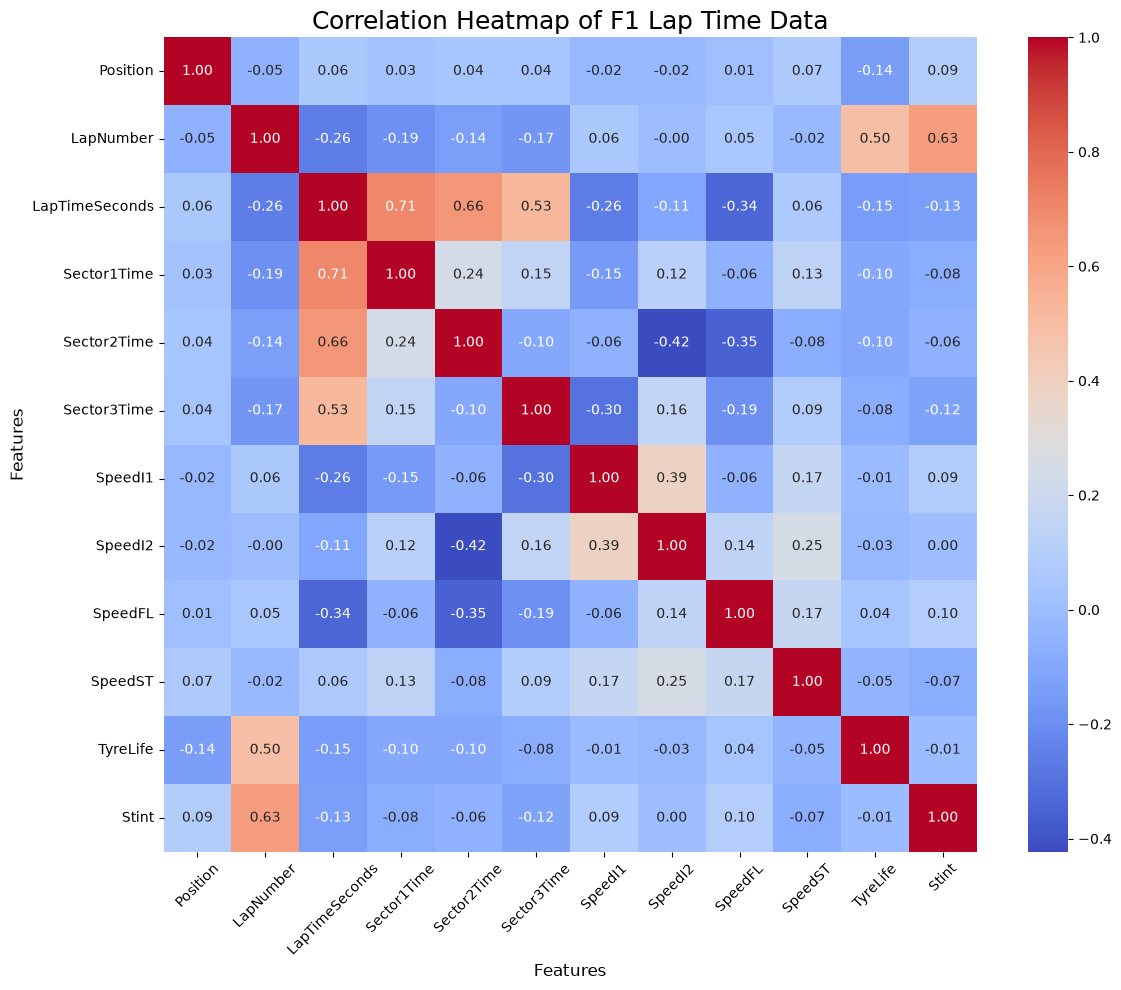

In [11]:
# Correlation Heatmap
numerical_columns = ['Position', 'LapNumber', 'LapTimeSeconds', 
                     'Sector1Time', 'Sector2Time', 'Sector3Time',
                     'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 
                     'TyreLife', 'Stint']


df_analysis = df_full_clean.copy()
df_analysis = df_analysis[numerical_columns]

plt.figure(figsize=(12, 10))
sns.heatmap(df_analysis.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of F1 Lap Time Data", fontsize=18)
plt.xlabel("Features", fontsize=12)
plt.tick_params(axis='x', labelrotation=45)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.savefig(eda_plots_dir / "01_correlation_heatmap.png", dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

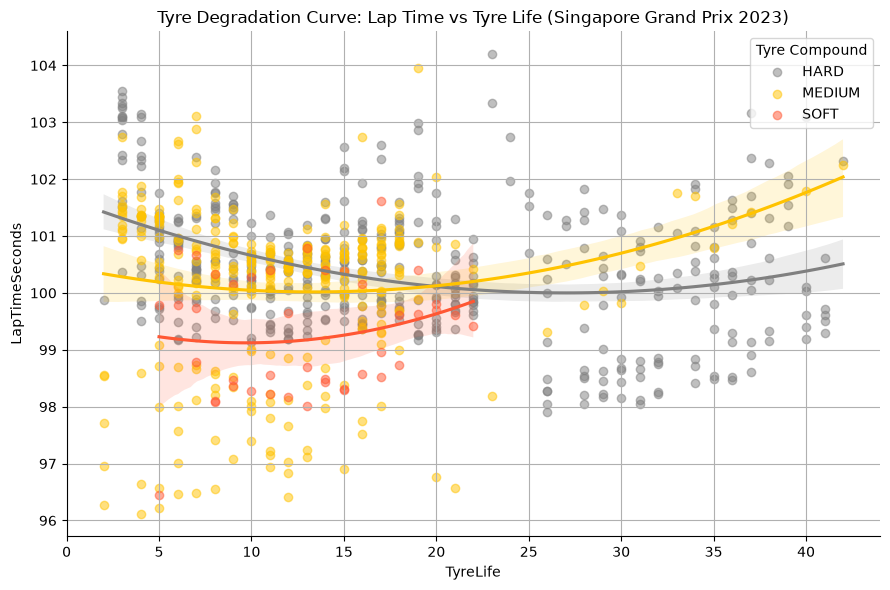

<Figure size 1000x600 with 0 Axes>

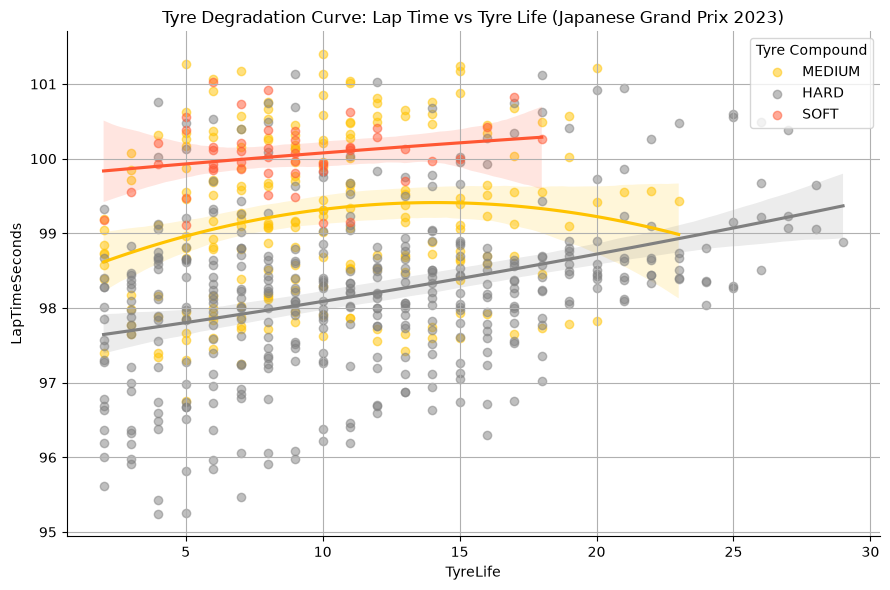

<Figure size 1000x600 with 0 Axes>

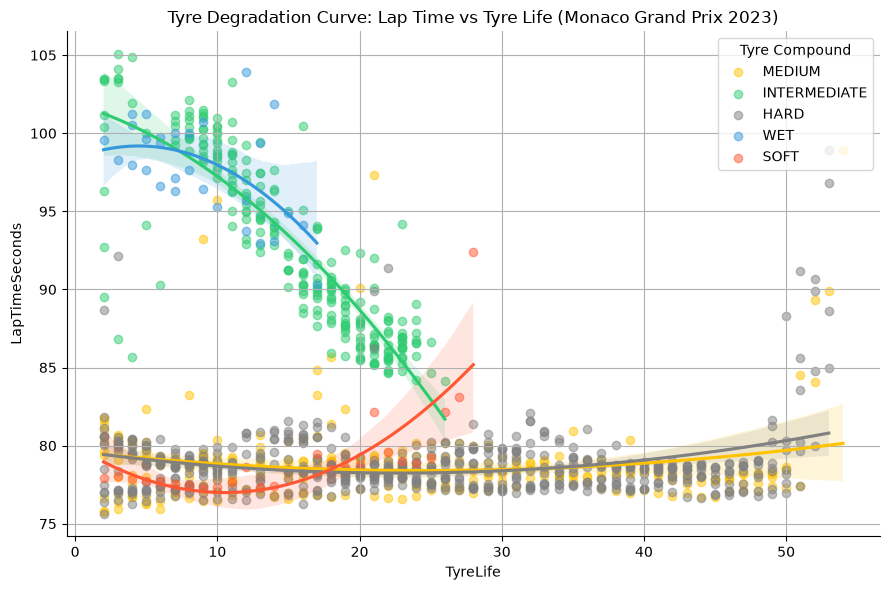

In [ ]:
# Tyre Degradation Curve: Lap Time vs Tyre Life

def plot_tyre_degradation(df, event='Italian Grand Prix', year=2023, png_name='tyre_degradation_curve'):
    sample_df = df[(df['Event'] == event) & (df['Year'] == year)]

    # only keep data where all the track status flags are 0 (no safety car, no red flag, no VSC, no pit closed, no SC ending)
    sample_df = sample_df[(sample_df['IsSafetyCar'] == 0) & 
                           (sample_df['IsRedFlag'] == 0) & 
                           (sample_df['IsVSC'] == 0) & 
                           (sample_df['IsPitClosed'] == 0) & 
                           (sample_df['IsSCEnding'] == 0)]
    
    # cap the lap times to a maximum of 120 seconds to remove outliers
    sample_df = sample_df[sample_df['LapTimeSeconds'] <= 110]

    color_palette = {
        'SOFT': '#FF5733',          # Red
        'MEDIUM': '#FFC300',        # Yellow
        'HARD': '#808080',          # Gray
        'INTERMEDIATE': '#2ECC71',  # Green
        'WET': '#3498DB'            # Blue
    }
    plt.figure(figsize=(10, 6))
    sns.lmplot(
        data=sample_df, 
        x='TyreLife', 
        y='LapTimeSeconds', 
        hue='Compound', 
        palette=color_palette,
        height=6, 
        aspect=1.5,
        scatter_kws={'alpha': 0.5},
        order=2,
        legend=False
    )
    plt.title(f'Tyre Degradation Curve: Lap Time vs Tyre Life ({event} {year})')
    plt.grid(True)
    plt.legend(title='Tyre Compound', loc='upper right')
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()



plot_tyre_degradation(df_full_clean, event='Singapore Grand Prix', year=2023, png_name='02_tyre_degradation_Singapore_2023.png')
plot_tyre_degradation(df_full_clean, event='Japanese Grand Prix',  year=2023, png_name='03_tyre_degradation_Japanese_2023.png')
plot_tyre_degradation(df_full_clean, event='Monaco Grand Prix',    year=2023, png_name='04_tyre_degradation_Monaco_2023.png')

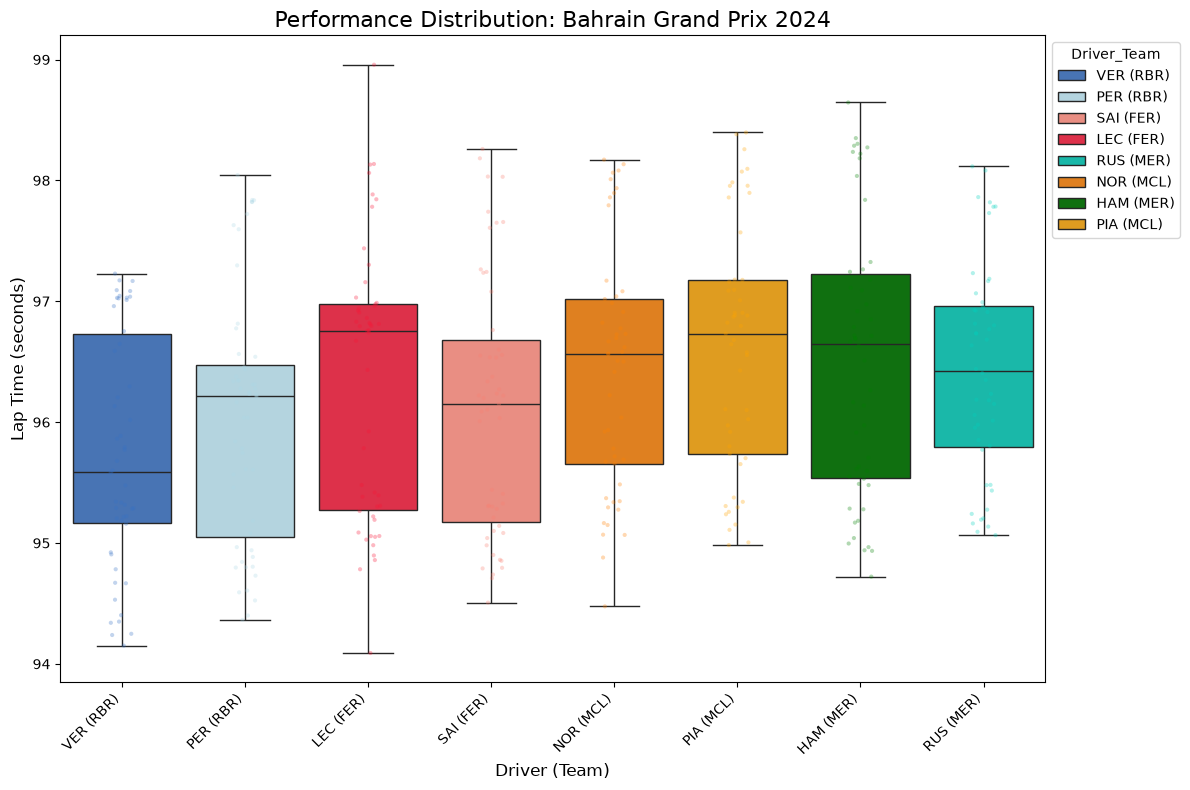

In [15]:
# Driver and Team Effect on Lap Time
def plot_driver_team_effect(df, event='Singapore Grand Prix', year=2023, png_name='driver_team_effect'):
    # Filter the dataframe for the specified event and year, and only include the big 4 teams
    team_abbr = {'Red Bull Racing': 'RBR', 'Ferrari': 'FER', 'McLaren': 'MCL', 'Mercedes': 'MER'}
    subset = df[(df['Team'].isin(team_abbr.keys())) & (df['Event'] == event) & (df['Year'] == year)].copy()
    subset['Driver_Team'] = subset['Driver'] + ' (' + subset['Team'].map(team_abbr) + ')'

    custom_order = ['VER (RBR)', 'PER (RBR)', 'LEC (FER)', 'SAI (FER)', 'NOR (MCL)', 'PIA (MCL)', 'HAM (MER)', 'RUS (MER)']

    color_map = {
        'VER (RBR)': '#3671C6', 'PER (RBR)': 'lightblue',
        'LEC (FER)': '#F91536', 'SAI (FER)': 'salmon',
        'NOR (MCL)': '#FF8000', 'PIA (MCL)': '#FFA500',
        'HAM (MER)': 'green', 'RUS (MER)': '#00D2BE'
    }

    plt.figure(figsize=(12, 8))

    sns.boxplot(
        data=subset, x='Driver_Team', y='LapTimeSeconds', 
        hue='Driver_Team',       
        palette=color_map, 
        order=custom_order,      
        fliersize=0,
        legend=True             
    )
    sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))
    
    sns.stripplot(
        data=subset, x='Driver_Team', y='LapTimeSeconds', 
        hue='Driver_Team',       
        palette=color_map,
        order=custom_order,
        size=3, alpha=0.3,
        legend=False             
    )

    plt.title(f'Performance Distribution: {event} {year}', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Driver (Team)', fontsize=12)
    plt.ylabel('Lap Time (seconds)', fontsize=12)
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()

plot_driver_team_effect(df_full_clean, event='Bahrain Grand Prix', year=2024, png_name='05_driver_team_effect_Bahrain_2024.png')

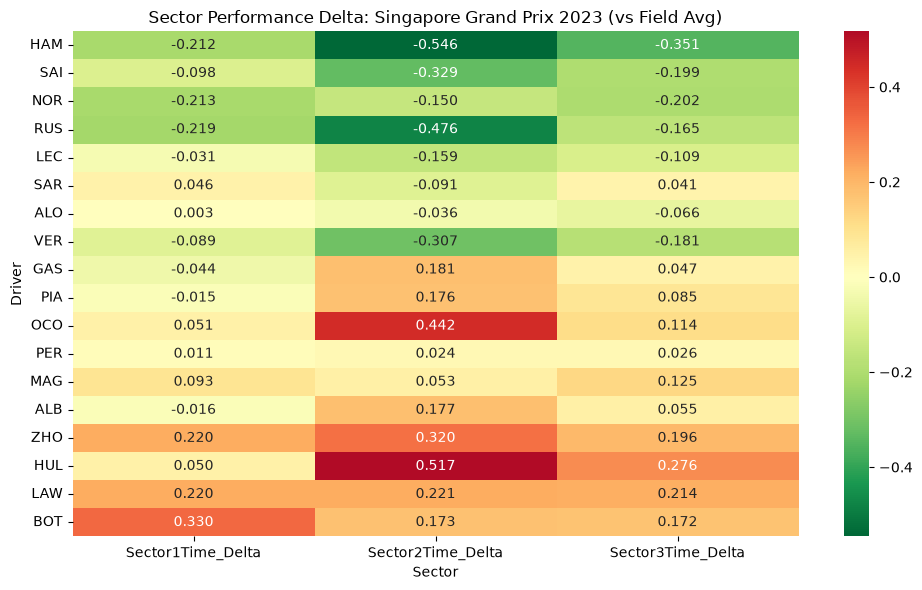

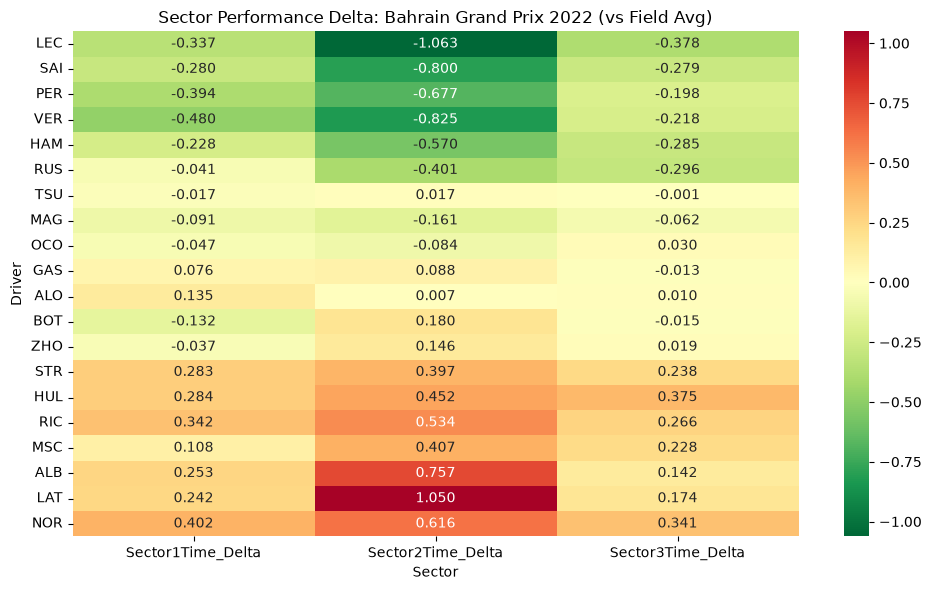

In [17]:
# Sector Performance Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

def plot_sector_performance_heatmap(df, event='Singapore Grand Prix', year=2023, png_name='sector_performance_heatmap'):
    # 1. Filter the dataframe for the specified event and year
    subset = df[(df['Event'] == event) & (df['Year'] == year)].copy()
    sector_cols = ['Sector1Time', 'Sector2Time', 'Sector3Time']

    # 2. Calculate the delta from the mean for each sector
    for col in sector_cols:
        subset[f'{col}_Delta'] = subset[col] - subset[col].mean()

    subset = subset.dropna(subset=['LapTimeSeconds'])
    driver_order = subset.groupby('Driver')['LapTimeSeconds'].median().sort_values().index

    # 4. Pivot the dataframe to have drivers as rows and sectors as columns
    pivot_df = subset.pivot_table(index='Driver', values=[f'{c}_Delta' for c in sector_cols])
    pivot_df = pivot_df.reindex(driver_order)
    
    # 5. Create the heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_df, annot=True, cmap='RdYlGn_r', center=0, fmt=".3f")
    plt.title(f'Sector Performance Delta: {event} {year} (vs Field Avg)')
    plt.xlabel('Sector')
    plt.ylabel('Driver')
    plt.tight_layout()
    plt.savefig(eda_plots_dir / png_name, dpi=300)
    plt.show()

plot_sector_performance_heatmap(df_full_clean, event='Singapore Grand Prix', year=2023, png_name='06_sector_performance_heatmap_Singapore_2023.png')
plot_sector_performance_heatmap(df_full_clean, event='Bahrain Grand Prix', year=2022, png_name='07_sector_performance_heatmap_Bahrain_2022.png')

<Figure size 1000x600 with 0 Axes>

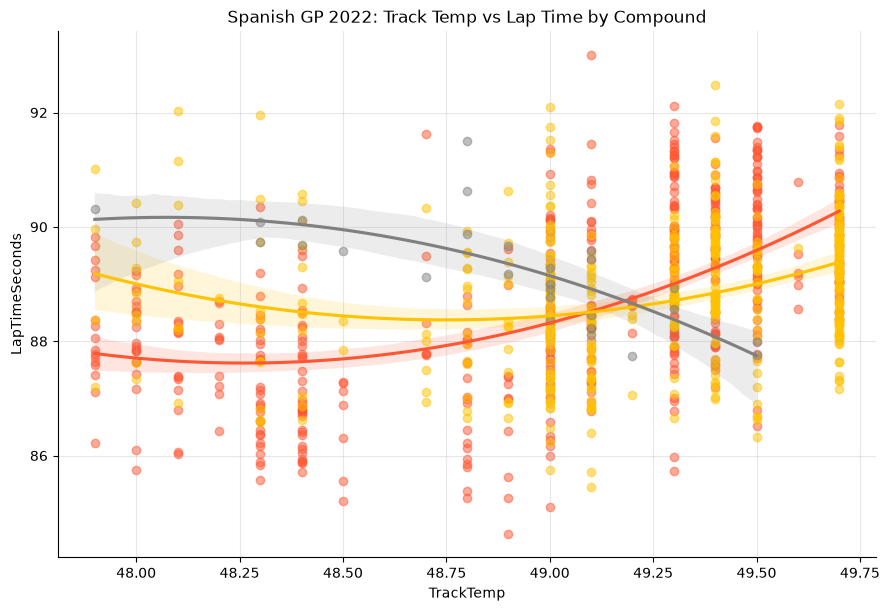

In [ ]:
# Scatter Plot: Track Temperature vs Lap Time by Compound

# Filter the dataframe for the Singapore Grand Prix 2023
spanish_2022 = df_full_clean[(df_full_clean['Year'] == 2022) & (df_full_clean['Event'] == 'Spanish Grand Prix')]

color_palette = {
    'SOFT': '#FF5733',          # Red
    'MEDIUM': '#FFC300',        # Yellow
    'HARD': '#808080',          # Gray
    'INTERMEDIATE': '#2ECC71',  # Green
    'WET': '#3498DB'            # Blue
}

# plot the scatter plot with regression lines for each compound
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=spanish_2022, 
    x='TrackTemp', 
    y='LapTimeSeconds', 
    hue='Compound', 
    palette=color_palette,
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.5},
    order=2,
    legend=False
)

plt.title('Spanish GP 2022: Track Temp vs Lap Time by Compound')
plt.grid(True, alpha=0.3)
plt.savefig(eda_plots_dir / "08_track_temp_vs_lap_time_Spanish_2022.png", dpi=300)
plt.show()

# Feature Engineering

**Additional Feature Engineering & Data Notes**

1. **Extended Environmental & Compound Indexing**
   * **Humidity & Pressure:** Atmospheric density affects downforce/vertical load and tire cooling, shifting optimal tire working windows.
   * **`TrackTemp_Normalized_By_Compound`:** Interaction feature mapping track surface temperature against Pirelli compound hardness (C1–C5) to model compound-specific thermal degradation.

2. **Regulatory Shift Handling (`RuleSet`)**
   * **Categorical Rule Flag:** Include discrete rule-epoch indicators (e.g., `2018–2021`, `2022–2025`, `2026+`) to account for structural shifts in vehicle mass, aerodynamics, and tire physics.

3. **Dynamic Vehicle Physics & Performance Drift**
   * **Fuel Burn & Mass Sensitivity:** Model dynamic vehicle weight loss (~1.5 kg/lap) to unmask underlying tire degradation from weight-reduction pace gains (~0.3s / 10kg).
   * **In-Season Upgrades:** Track team baseline pace shifts across major aerodynamic/chassis update packages.

4. **Time-Decay Sample Weighting**
   * **Exponential Recency Weighting:** Apply sample weights $W_t = e^{-\lambda (T_{\text{current}} - T_{\text{sample}})}$ during LSTM/Bayesian training to prioritize recent car iterations and modern tire formulations.

In [ ]:
# Feature Engineering: LapTimeDelta, TyreLifeSquared, Stint_Age, Relative_Gap, DRS_Active

def engineer_features(df):
    df = df.copy()
    
    # 1. Sort the dataframe by Year, Event, Driver, and LapNumber to ensure proper time-series continuity
    df = df.sort_values(['Year', 'Event', 'Driver', 'LapNumber'])
    
    # --- LapTimeDelta ---
    df['LapTimeDelta'] = df.groupby(['Year', 'Event', 'Driver'])['LapTimeSeconds'].diff()
    df['LapTimeDelta'] = df['LapTimeDelta'].fillna(0).clip(lower=-2.0, upper=2.0)
    
    # --- Tyre & Stint Features ---
    df['TyreLifeSquared'] = df['TyreLife'] ** 2
    df['Stint_Age'] = df.groupby(['Year', 'Event', 'Driver', 'Stint']).cumcount() + 1
    
    # --- Relative Gap & DRS ---
    df = df.sort_values(['Year', 'Event', 'LapNumber', 'Position'])
    
    # Position=1 (first car) has no car in front, so .diff() will be NaN -> fill with 999 to indicate leading Free Air
    df['Relative_Gap'] = df.groupby(['Year', 'Event', 'LapNumber'])['Time'].diff().fillna(999)
    
    # DRS is active if the relative gap is between 0 and 1 second (inclusive)
    df['DRS_Active'] = ((df['Relative_Gap'] > 0.0) & (df['Relative_Gap'] <= 1.0)).astype(int)
    
    # Clip Relative_Gap to a maximum of 10.0 (first car with 999 will become 10.0, avoiding issues with Scaler)
    df['Relative_Gap'] = df['Relative_Gap'].clip(upper=10.0)
    
    # Re-sort the dataframe by Year, Event, Driver, and LapNumber to maintain time-series continuity (important for LSTM)
    df = df.sort_values(['Year', 'Event', 'Driver', 'LapNumber']).reset_index(drop=True)
    
    return df

# Apply feature engineering to the cleaned dataframe
df_full_eng = engineer_features(df_full_clean)
df_full_eng.drop(columns=['Time', 'Position'], inplace=True, errors='ignore')

print(df_full_eng.columns)

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'LapTimeSeconds',
       'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife',
       'FreshTyre', 'Stint', 'IsSafetyCar', 'IsRedFlag', 'IsVSC',
       'IsPitClosed', 'IsSCEnding', 'AirTemp', 'TrackTemp', 'Rainfall',
       'LapTimeDelta', 'TyreLifeSquared', 'Stint_Age', 'Relative_Gap',
       'DRS_Active'],
      dtype='object')


Feature Statistics: count    115725.000000
mean         -0.059413
std           0.601761
min          -2.000000
25%          -0.272000
50%          -0.015000
75%           0.204000
max           2.000000
Name: LapTimeDelta, dtype: float64
Extreme LapTimeDelta values (> 2.0 or < -2.0): 0 rows


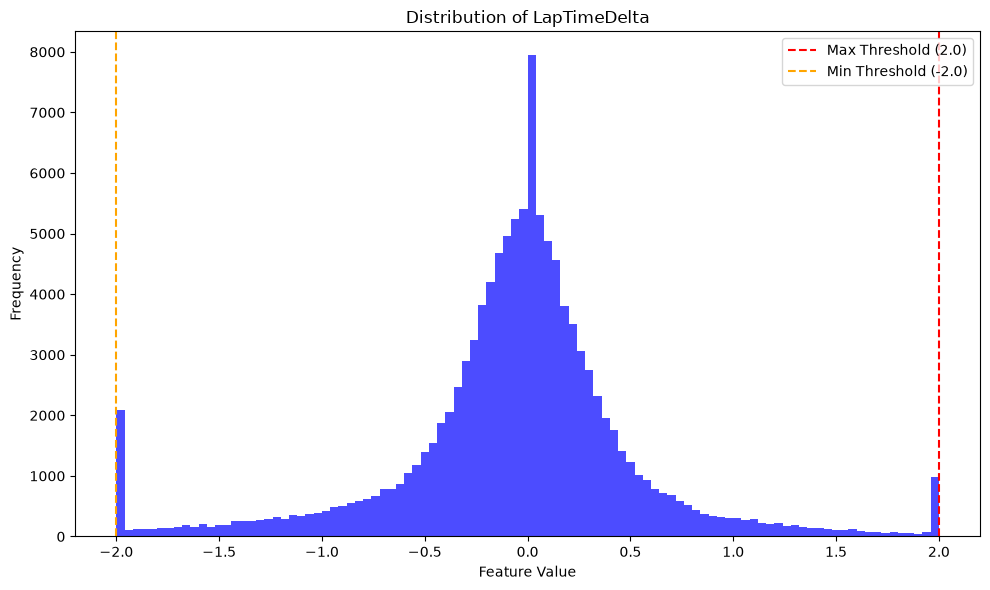

Feature Statistics: count    115725.000000
mean          4.264327
std           3.526001
min           0.002000
25%           1.255000
50%           2.831000
75%           7.496000
max          10.000000
Name: Relative_Gap, dtype: float64
Extreme Relative_Gap values (> 10 or < 0): 0 rows


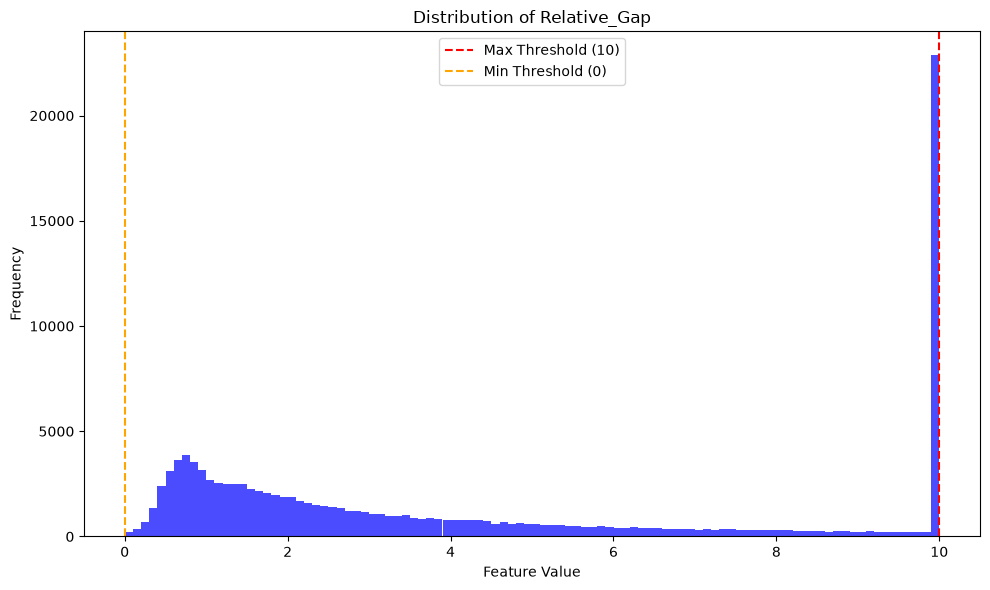

In [ ]:
# A small check on numerical features to see if they are within reasonable ranges

def check_extreme_values(df, feature, thre_min=5, thre_max=5, save_path=None):
    print(f"Feature Statistics: {df[feature].describe()}")
    extreme_deltas = df[(df[feature] > thre_max) | (df[feature] < thre_min)]
    print(f"Extreme {feature} values (> {thre_max} or < {thre_min}): {len(extreme_deltas)} rows")

    # Plot the distribution
    plt.figure(figsize=(10, 6))
    plt.hist(df[feature], bins=100, color='blue', alpha=0.7)
    # add vertical lines for thresholds
    plt.axvline(x=thre_max, color='red', linestyle='--', label=f'Max Threshold ({thre_max})')
    plt.axvline(x=thre_min, color='orange', linestyle='--', label=f'Min Threshold ({thre_min})')
    
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of ' + feature)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(feature_eng_plots_dir / save_path, dpi=300)
    plt.show()


check_extreme_values(df_full_eng, 'LapTimeDelta', thre_min=-2.0, thre_max=2.0, save_path="01_lap_time_delta_dist.png")

check_extreme_values(df_full_eng, 'Relative_Gap', thre_min=0, thre_max=10, save_path="02_relative_gap_dist.png")

In [ ]:
# Reorder to put target feature at the end for better readability and model training
desired_order = [   'Year', 'Event', 'Driver', 'Team', 'LapNumber',                                     # Basic Info
                    'Sector1Time', 'Sector2Time', 'Sector3Time', 'IsPersonalBest',                      # Lap performance
                    'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',                                         # Speed
                    'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife', 'TyreLifeSquared', 'Compound',       # Tyre Strategy
                    'Relative_Gap', 'DRS_Active',                                                       # Relative Gap and DRS
                    'IsSafetyCar', 'IsRedFlag', 'IsVSC','IsPitClosed', 'IsSCEnding',                    # Track Status
                    'AirTemp', 'TrackTemp', 'Rainfall',                                                 # Weather Conditions
                    'LapTimeSeconds','LapTimeDelta',                                                    # Target Feature
]

 
df_no_extreme = reorder_columns(df_full_eng, desired_order)
df_no_extreme.columns

Index(['Year', 'Event', 'Driver', 'Team', 'LapNumber', 'Sector1Time',
       'Sector2Time', 'Sector3Time', 'IsPersonalBest', 'SpeedI1', 'SpeedI2',
       'SpeedFL', 'SpeedST', 'Stint', 'Stint_Age', 'FreshTyre', 'TyreLife',
       'TyreLifeSquared', 'Compound', 'Relative_Gap', 'DRS_Active',
       'IsSafetyCar', 'IsRedFlag', 'IsVSC', 'IsPitClosed', 'IsSCEnding',
       'AirTemp', 'TrackTemp', 'Rainfall', 'LapTimeSeconds', 'LapTimeDelta'],
      dtype='object')

# Preprocessor - Fit and Transform of Split Data